In [2]:
import matplotlib.pyplot as plt

# 设置Matplotlib全局字体（支持中文和符号）
plt.rcParams['font.family'] = 'sans-serif'        # 使用无衬线字体
plt.rcParams['font.sans-serif'] = ['SimHei']

(38, 5)
(38,)
[10 11 15 16 20 22 26 29]
[8.46 3.23 4.33 3.69 9.6  3.8  4.8  5.7 ]
SVR(C=1.5, gamma=0.3)
SVR_MAE:0.524,1.647,SVR_RMSE:0.773,2.032


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_01.png


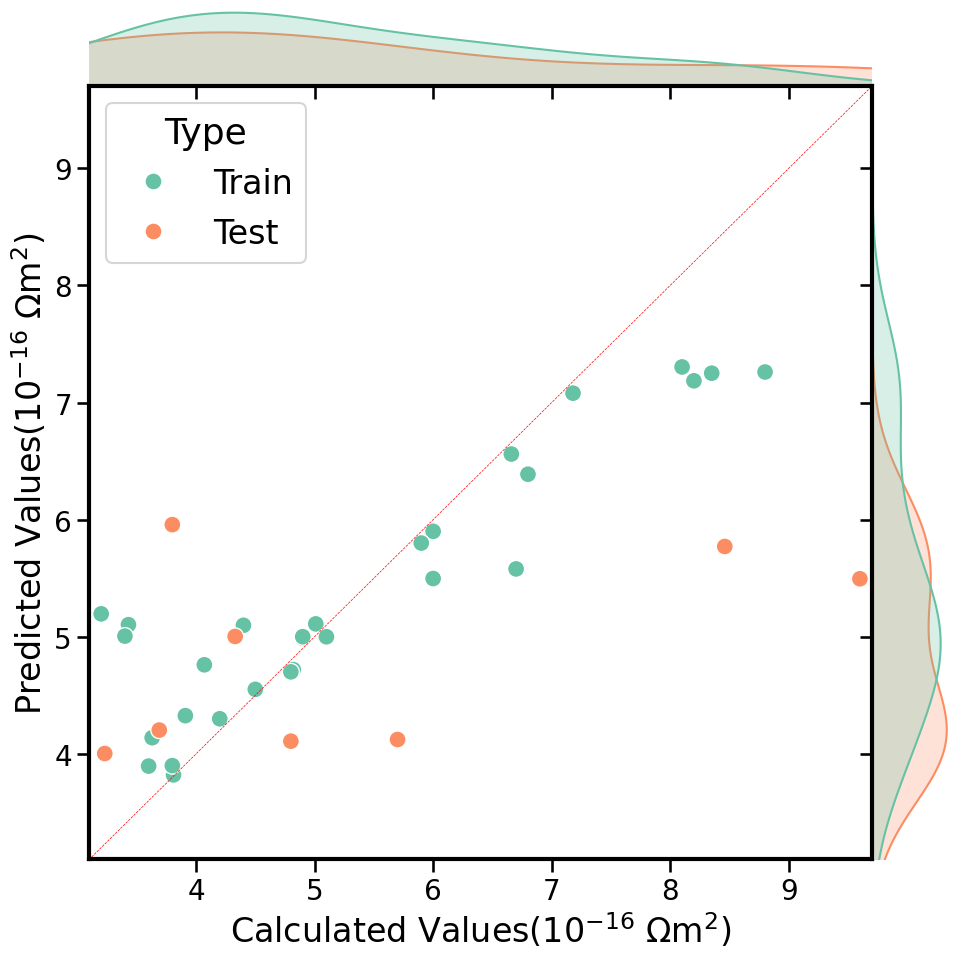

[ 2 25 30 31 32 33 35 37]
[6.66 5.1  4.8  5.9  4.9  4.5  3.8  6.  ]
SVR(C=1.5, gamma=0.3)
SVR_MAE:0.725,0.735,SVR_RMSE:1.06,0.917


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_02.png


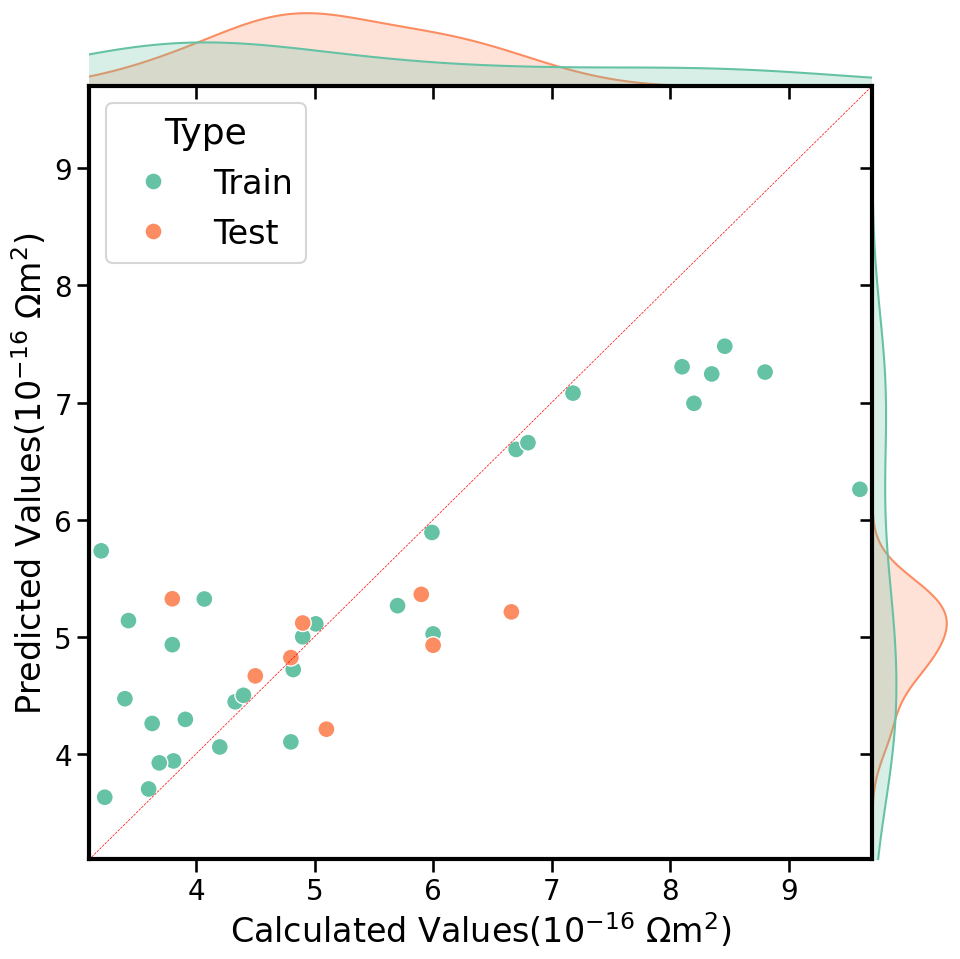

[ 5  7  8 13 14 17 28 34]
[6.7  3.91 5.99 7.18 8.2  3.43 4.2  4.4 ]
SVR(C=1.5, gamma=0.3)
SVR_MAE:0.665,1.462,SVR_RMSE:1.051,1.639


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_03.png


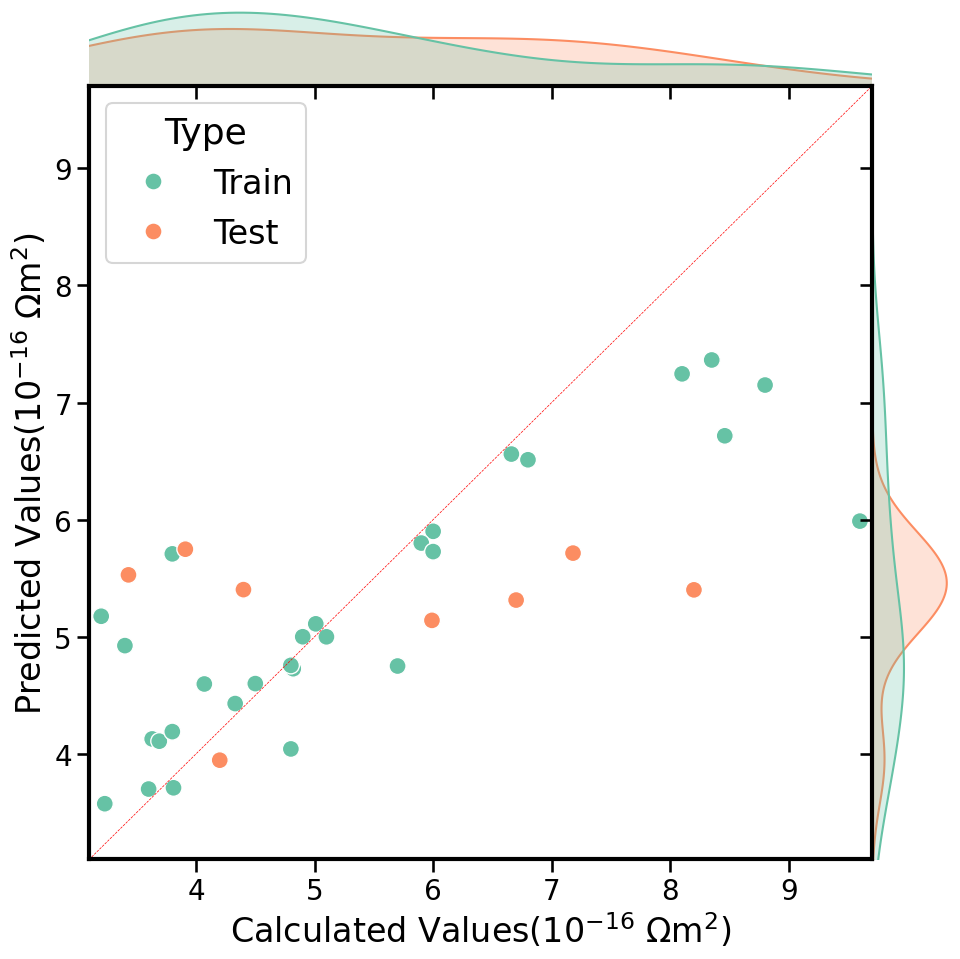

[ 1  4  6 12 23 24 27]
[5.01 4.07 8.1  3.63 3.2  6.   3.6 ]
SVR(C=1.5, gamma=0.3)
SVR_MAE:0.547,1.774,SVR_RMSE:0.821,2.006


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_04.png


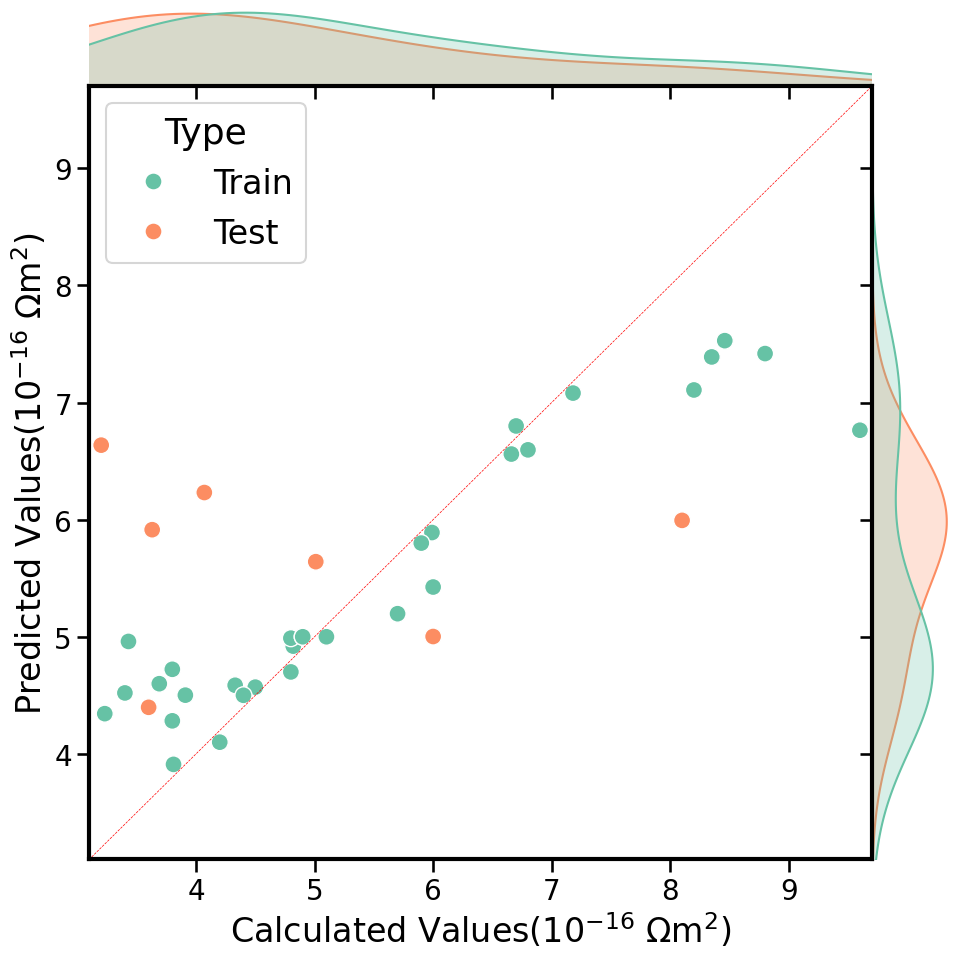

[ 0  3  9 18 19 21 36]
[8.8  4.82 3.81 8.35 6.8  3.4  4.9 ]
SVR(C=1.5, gamma=0.3)
SVR_MAE:0.626,1.545,SVR_RMSE:0.97,1.932


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


已保存：svr_kfold_plots\fold_05.png


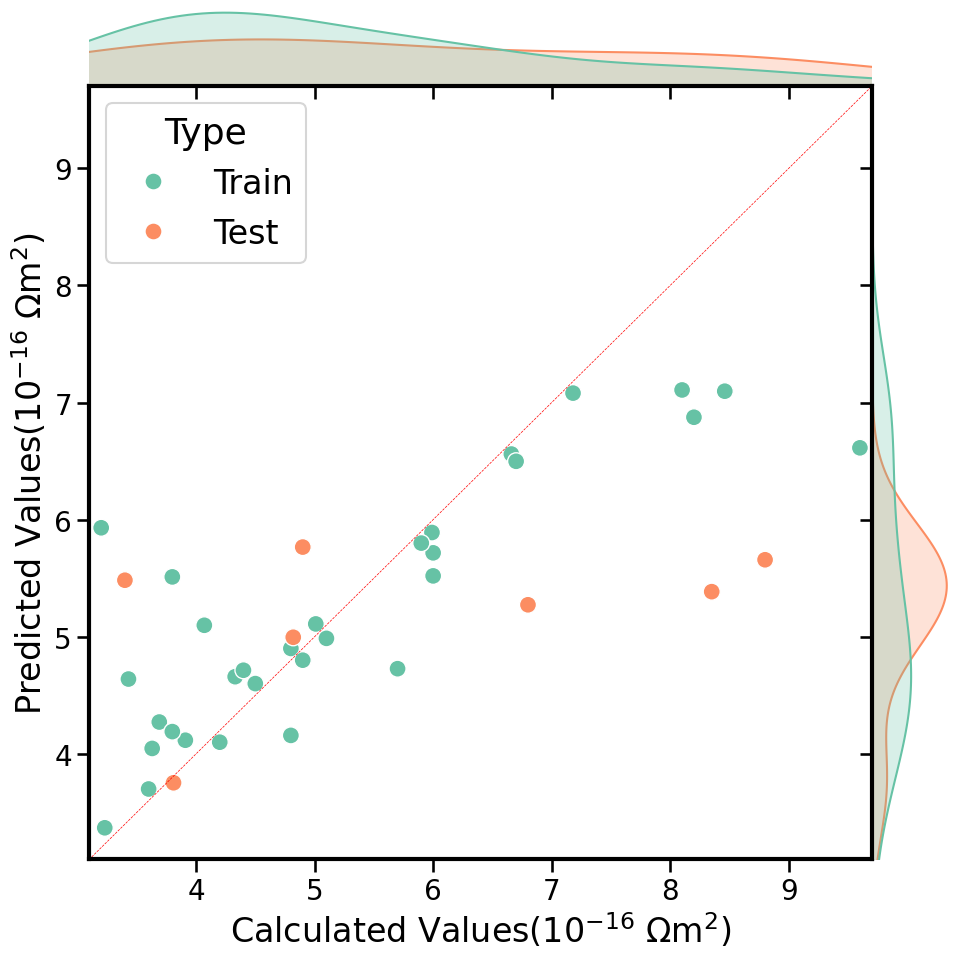

SVR_MAE:0.617+-0.074,1.433+-0.364,SVR_RMSE:0.935+-0.118,1.705+-0.418,SVR_MAPE:12.791+-0.0,25.391+-0.0


['model.svr']

In [1]:
# from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
import joblib
from sklearn.metrics import mean_absolute_percentage_error

File = '../data.4/em-wt-10'
X,y= sub_data(File)
X,y= pre_data(X,y)
X=X[:38,:]
y=y[:38]
# X=np.delete(X,[20],axis= 0) # 该点为 大于9的点，一个单点
X=np.delete(X,[0,5,6],axis= 1)
print(X.shape)
print(y.shape)

import os
# 创建专用保存目录
save_dir = "svr_kfold_plots"
os.makedirs(save_dir, exist_ok=True)





R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]
MAPE_train_a=[]
MAPE_test_a=[]
ns=5
nr=1
kf = RepeatedKFold(n_splits=ns, n_repeats=nr, random_state=0)
for fold_num, (train_index, test_index) in enumerate(kf.split(X), 1):
  X_train, y_train = X[train_index], y[train_index]
  X_test, y_test = X[test_index], y[test_index]
  print(test_index)
  print(y[test_index])
  svr_rbf = SVR(kernel="rbf", C=1.5, gamma=0.3 , epsilon=0.1)
  svr_rbf.fit(X_train, y_train)
  print(svr_rbf)
 
  y_pre1=svr_rbf.predict(X_train)
  y_pre2=svr_rbf.predict(X_test)
    
  R2_train=round(svr_rbf.score(X_train, y_train),3)
  R2_test=round(svr_rbf.score(X_test, y_test),3)
  MAE_train = round(mean_absolute_error(y_train,y_pre1),3)
  MAE_test =  round(mean_absolute_error(y_test,y_pre2),3)
  MSE_train = round(mean_squared_error(y_train,y_pre1),3)
  MSE_test = round(mean_squared_error(y_test,y_pre2),3)
  RMSE_train = round(math.sqrt(MSE_train),3)
  RMSE_test = round(math.sqrt(MSE_test),3)
  MAPE_train = round(mean_absolute_percentage_error(y_train, y_pre1) * 100, 3)
  MAPE_test= round(mean_absolute_percentage_error(y_test, y_pre2) * 100, 3)
  MAPE_train_a=[MAPE_train]
  MAPE_test_a=[MAPE_test]
  R2_train_a += [R2_train]
  R2_test_a += [R2_test]
  MAE_train_a += [MAE_train]
  MAE_test_a += [MAE_test]
  MSE_train_a += [MSE_train]
  MSE_test_a += [MSE_test]
  RMSE_train_a += [RMSE_train]
  RMSE_test_a += [RMSE_test]
  print("SVR_MAE:%s,%s,SVR_RMSE:%s,%s" %(MAE_train,MAE_test,RMSE_train,RMSE_test))
  plot_train_test_results1( y_train, y_test, y_pre1, y_pre2, fname=f"fold_{fold_num:02d}", output=True,plt_prop=True,save_dir=save_dir )
  # plot_train_test_results(y_train,y_test,y_pre1,y_pre2,output=True,fname='SVR')
R2_train_mean=round(np.mean(R2_train_a),3)
R2_train_std=round(np.std(R2_train_a),3)
R2_test_mean=round(np.mean(R2_test_a),3)
R2_test_std=round(np.std(R2_test_a),3)
MAE_train_mean=round(np.mean(MAE_train_a),3)
MAE_train_std=round(np.std(MAE_train_a),3)
MAE_test_mean=round(np.mean(MAE_test_a),3)
MAE_test_std=round(np.std(MAE_test_a),3)
MSE_train_mean=round(np.mean(MSE_train_a),3)
MSE_train_std=round(np.std(MSE_train_a),3)
MSE_test_mean=round(np.mean(MSE_test_a),3)
MSE_test_std=round(np.std(MSE_test_a),3)
RMSE_train_mean=round(np.mean(RMSE_train_a),3)
RMSE_train_std=round(np.std(RMSE_train_a),3)
RMSE_test_mean=round(np.mean(RMSE_test_a),3)
RMSE_test_std=round(np.std(RMSE_test_a),3)
MAPE_train_mean=round(np.mean(MAPE_train_a),3)
MAPE_train_std=round(np.std(MAPE_train_a),3)
MAPE_test_mean=round(np.mean(MAPE_test_a),3)
MAPE_test_std=round(np.std(MAPE_test_a),3)
print("SVR_MAE:%s+-%s,%s+-%s,SVR_RMSE:%s+-%s,%s+-%s,SVR_MAPE:%s+-%s,%s+-%s" %(MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std,MAPE_train_mean,MAPE_train_std,MAPE_test_mean,MAPE_test_std))

# plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1,
                       # train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True):
#plot_learning_curve(SVR(),SVR,X,y,n_jobs=1,train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True)
# 保存模型
joblib.dump(svr_rbf, 'model.svr')

# 2 最远点采样

(37, 5)
(37,)
[np.int32(35), np.int64(18), np.int64(6), np.int64(14), np.int64(32), np.int64(7), np.int64(16), np.int64(12), np.int64(10), np.int64(0), np.int64(2), np.int64(34), np.int64(19), np.int64(13), np.int64(30), np.int64(21), np.int64(1), np.int64(8), np.int64(22), np.int64(15), np.int64(11), np.int64(28), np.int64(17), np.int64(33), np.int64(9), np.int64(3), np.int64(24), np.int64(20), np.int64(36), np.int64(5)]
SVR(C=3, epsilon=0.2, gamma=0.1)
0.602,0.598,0.869,0.782,13.502,12.694


D:\conda\Lib\site-packages\seaborn\axisgrid.py:1883: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=self.x, ax=self.ax_marg_x, **kwargs)
D:\conda\Lib\site-packages\seaborn\axisgrid.py:1889: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(y=self.y, ax=self.ax_marg_y, **kwargs)


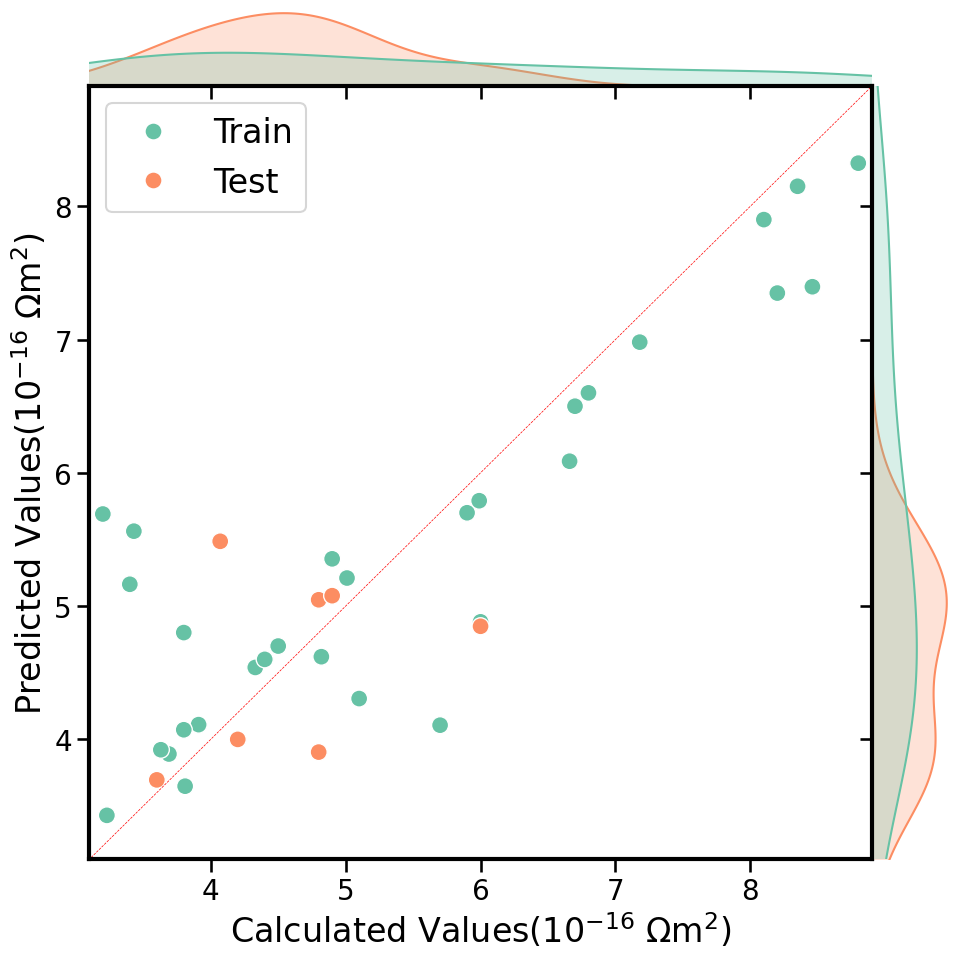

SVR_fps_MAE:0.602+-0.0,0.598+-0.0,SVR_fps_RMSE:0.869+-0.0,0.782+-0.0,SVR_fps_MAPE:13.502+-0.0,12.694+-0.0


['model.svr_fps']

In [3]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from modules import *
from sklearn.svm import SVR
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
import joblib

# 函数定义部分为最远点采样
def extdata(File,st='\t'):
    data1=open(File,'r+')
    X,y=[],[]
    for i, line in enumerate(data1):
        data=line.split(st)
        if len(data) < 5:
           continue
        else:

          for j in range(0,int(len(data))-1):
            X += [float(data[j])]
        y += [float(data[-1])]
    
    m=len(X)
    n=len(y)
    X=np.array(X).reshape(int(n),int(m/n))
    y=np.array(y)
    
    #X=np.delete(X,[5,6,10],axis=1)
    return X,y

## 02 sampleing the first point:
# centre: the center of points
# random: random sampling
def first_point(X,method='center',rand_seed=20):
    if method == 'center':
       # calculate the center of point sets
       points=np.array([np.sum(X,axis=0)/X.shape[0]])
       distances = cdist( points, X,'euclidean')
       nearest_index = np.argmin(distances)
       fpoint = X[nearest_index]
       item= [ nearest_index ]
    elif method == 'random':
       # sampling via random bumber
      
       np.random.seed(int(rand_seed))
       item=np.random.randint(0,X.shape[0],size=1)
       fpoint=X[item]
    else:
       print('No other methods are adopted!')
    #distance_fp=np.sum((X-fpoint)**2,axis=1)
    return fpoint,item

## 03 calculating the distance between any two points
# criterion=['amount',3]
# criterion=['gra_dis',0.5]
def sampling(X,points,item,criterion=['gra_dis',1]):
    # distances bewteen points and first piont
    dis=np.sum((X-points)**2,axis=1)
    items=list(item) 
    center_dis=[]
    if criterion[0] == 'amount':
      for i in range(criterion[1]-1):
        # find the point farest from all sampling points
        new_point=X[np.argmax(dis)]
        points=np.vstack((points,[new_point]))
        items += [np.argmax(dis)]
        c1=np.array([np.sum(points[:-1,:],axis=0)/points.shape[0]])
        c2=np.array([np.sum(points,axis=0)/points.shape[0]])
        center_dis += [np.sum((c1-c2)**2,axis=1)]
        # find the minimun distance between every unsampling points and all sampling points 
        dis=np.minimum(dis,np.sum((X-new_point)**2,axis=1))
    elif criterion[0] == 'gra_dis':
      for j in range(X.shape[0]):     
        new_point=X[np.argmax(dis)]
        points=np.vstack((points,[new_point]))
        items += [np.argmax(dis)]
        # centers of sampling data this time and last time
        c1=np.array([np.sum(points[:-1,:],axis=0)/points.shape[0]])
        c2=np.array([np.sum(points,axis=0)/points.shape[0]])  
        center_dis += [np.sum((c1-c2)**2,axis=1)]
        # if the distance between centers of this and last times is smaller than the criterion 
        # or samping  all points, then finish!
        
        if (np.sum((c1-c2)**2,axis=1) <=float(criterion[1])**2) or (points.shape == X.shape): 
           #print(np.sum((c1-c2)**2,axis=1))
           print(f'{j+2} sampling Finish!')
           break
        else:
           #print(np.sum((c1-c2)**2,axis=1))
           dis=np.minimum(dis,np.sum((X-new_point)**2,axis=1))
    return points,items,np.sqrt(np.array(center_dis))

if __name__ == '__main__':

  File = '../data.4/em-wt-10'
  X1,y1= sub_data(File)
  X1,y1= pre_data(X1,y1)
  X1=X1[:38,:]
  y1=y1[:38]
  X1=np.delete(X1,[0,5,6],axis= 1)
  X1=np.delete(X1,[20],axis= 0 )
  y1=np.delete(y1,[20],axis = 0)
  print(X1.shape)
  print(y1.shape)
  method_1stp='random'
  fpoint,item=first_point(X1,method=method_1stp)
  points,items,center_dis = sampling(X1,fpoint,item,criterion=['amount',30]) 
  

  
R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]
MAPE_train_a=[]
MAPE_test_a=[]
train_indices = items.copy()
print(train_indices)
X1_train = points.copy()
# 使用列表推导式和索引号从 array1 中选择元素
y1_train = np.array([y1[i] for i in train_indices])

test_indices = np.setdiff1d(np.arange(X1.shape[0]), train_indices)
X1_test = X1[test_indices]
y1_test = np.array([y1[i] for i in test_indices])


svr_rbf = SVR(kernel="rbf", C=3, gamma=0.1 , epsilon=0.2)
svr_rbf.fit(X1_train, y1_train)
print(svr_rbf)

y1_pre1=svr_rbf.predict(X1_train)
y1_pre2=svr_rbf.predict(X1_test)

R2_train=round(svr_rbf.score(X1_train, y1_train),3)
R2_test=round(svr_rbf.score(X1_test, y1_test),3)
MAE_train = round(mean_absolute_error(y1_train,y1_pre1),3)
MAE_test =  round(mean_absolute_error(y1_test,y1_pre2),3)
MSE_train = round(mean_squared_error(y1_train,y1_pre1),3)
MSE_test = round(mean_squared_error(y1_test,y1_pre2),3)
RMSE_train = round(math.sqrt(MSE_train),3)
RMSE_test = round(math.sqrt(MSE_test),3)
MAPE_train = round(mean_absolute_percentage_error(y1_train, y1_pre1) * 100, 3)
MAPE_test= round(mean_absolute_percentage_error(y1_test, y1_pre2) * 100, 3)
R2_train_a += [R2_train]
R2_test_a += [R2_test]
MAE_train_a += [MAE_train]
MAE_test_a += [MAE_test]
MSE_train_a += [MSE_train]
MSE_test_a += [MSE_test]
RMSE_train_a += [RMSE_train]
RMSE_test_a += [RMSE_test]
MAPE_train_a=[MAPE_train]
MAPE_test_a=[MAPE_test]
print("%s,%s,%s,%s,%s,%s" %(MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test))
plot_train_test_results(y1_train,y1_test,y1_pre1,y1_pre2,output=True,fname='SVR_FPS')

R2_train_mean=round(np.mean(R2_train_a),3)
R2_train_std=round(np.std(R2_train_a),3)
R2_test_mean=round(np.mean(R2_test_a),3)
R2_test_std=round(np.std(R2_test_a),3)
MAE_train_mean=round(np.mean(MAE_train_a),3)
MAE_train_std=round(np.std(MAE_train_a),3)
MAE_test_mean=round(np.mean(MAE_test_a),3)
MAE_test_std=round(np.std(MAE_test_a),3)
MSE_train_mean=round(np.mean(MSE_train_a),3)
MSE_train_std=round(np.std(MSE_train_a),3)
MSE_test_mean=round(np.mean(MSE_test_a),3)
MSE_test_std=round(np.std(MSE_test_a),3)
RMSE_train_mean=round(np.mean(RMSE_train_a),3)
RMSE_train_std=round(np.std(RMSE_train_a),3)
RMSE_test_mean=round(np.mean(RMSE_test_a),3)
RMSE_test_std=round(np.std(RMSE_test_a),3)
MAPE_train_mean=round(np.mean(MAPE_train_a),3)
MAPE_train_std=round(np.std(MAPE_train_a),3)
MAPE_test_mean=round(np.mean(MAPE_test_a),3)
MAPE_test_std=round(np.std(MAPE_test_a),3)
print("SVR_fps_MAE:%s+-%s,%s+-%s,SVR_fps_RMSE:%s+-%s,%s+-%s,SVR_fps_MAPE:%s+-%s,%s+-%s" %(MAE_train_mean,MAE_train_std,MAE_test_mean,MAE_test_std,RMSE_train_mean,RMSE_train_std,RMSE_test_mean,RMSE_test_std,MAPE_train_mean,MAPE_train_std,MAPE_test_mean,MAPE_test_std))

#plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=1,
                       # train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True):
#plot_learning_curve(SVR(),SVR,X,y,n_jobs=1,train_sizes=np.linspace(0.05, 1.0, 20), verbose=0, plot=True)
# 保存模型
joblib.dump(svr_rbf, 'model.svr_fps')

# 4. 预测

In [2]:
# 假设你已经训练并保存了模型
# 加载模型
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.svm import SVR
from scipy.stats import pearsonr
from modules import *
from sklearn.svm import SVR
from sklearn.decomposition import PCA
import joblib
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
import pandas as pd

# 准备新数据
File = '../data.4/em-wt-10'
X,y= sub_data(File)
X,y= pre_data(X,y)
X=X[43:]
y=y[43:]
X=np.delete(X,[0,5,6],axis= 1)
print(X.shape)
print(y.shape)


loaded_model = joblib.load('model.svr_fps')
predictions = loaded_model.predict(X)# 进行预测
df_predictions = pd.DataFrame(predictions, columns=['Prediction2'])# 使用pandas创建DataFrame
df_predictions.to_csv('pSVR-2.csv', index=False)# 将DataFrame保存为CSV文件

print(predictions.shape)
print("预测结果:", predictions)

min_value = np.min(predictions)# 输出最值及索引方便找位置
max_value = np.max(predictions)
max_index = np.argmax(predictions)
min_index = np.argmin(predictions)

(584, 5)
(584,)
(584,)
预测结果: [5.51814634 6.02437426 5.24153196 6.85825286 6.26391055 5.32678789
 5.3930266  6.10486782 6.90715527 4.60981966 3.6895742  4.01398409
 7.19487784 4.6408448  4.80138758 7.22256057 5.9155021  4.64116391
 3.40435727 4.34216123 5.00228474 5.57116337 5.22855965 5.9645025
 5.99611883 5.38726422 6.53965721 5.82083743 5.59200308 5.77852249
 6.25468101 6.60884117 4.91178289 4.08286168 4.830324   7.01290233
 5.34003232 5.38167269 6.93848293 5.28121843 3.51481411 3.67307751
 4.94186567 6.60978118 7.82661482 5.22636365 5.28146431 5.40575326
 6.22391302 5.18726026 5.1527068  6.13947836 6.1039534  5.81575347
 6.38981283 5.84774629 5.80603608 5.97354655 6.32553762 6.5222943
 5.17128983 4.61218479 5.3039917  6.90547308 5.69569797 5.69750847
 6.78954782 5.0892354  3.36382088 4.1408506  5.36539055 6.74326172
 5.21713981 5.55761113 5.57372019 6.19397519 5.41407955 6.23128673
 6.18518684 5.96626058 5.86246368 6.34978205 5.93508981 5.94815715
 6.08888905 6.36668912 6.49275777 5

D:\anaconda\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVR from version 1.5.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# 全部数据作为模型进行训练的结果

(38, 8)
(38,)


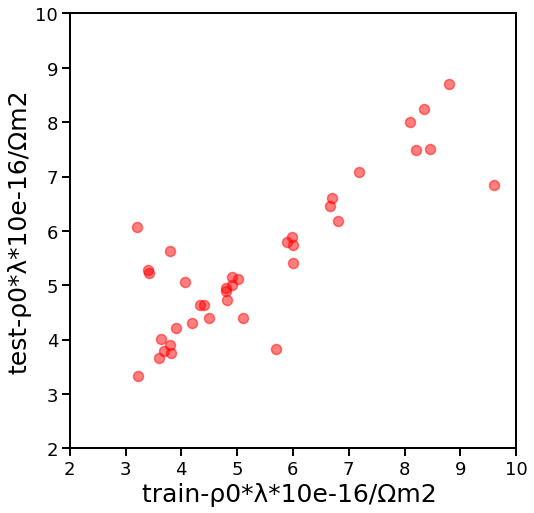

(583,)
预测结果: [6.04997315 6.76502765 6.46450931 7.1484855  6.90438989 5.549105
 5.49569668 6.01086929 7.69163632 4.5056518  3.56522112 3.51517301
 7.32900425 4.12730826 4.8089434  7.70175269 6.50423187 4.97073927
 3.52286508 4.06865718 4.87849094 5.84913839 5.48307572 6.30503309
 6.56942374 5.81046778 6.99054636 6.4830309  5.80794117 5.91439609
 6.25566876 7.4153124  4.52758249 3.74177416 4.30547761 7.13007107
 4.8944742  5.42301249 7.56432733 6.0476787  3.88995548 3.70602352
 4.63518067 6.22859797 7.75207021 5.5534352  5.24332674 5.66333795
 7.02108925 5.51500834 5.27106381 6.418955   6.56020948 6.44769933
 6.8252029  6.4252867  6.03336154 6.13346865 6.37414153 7.22203342
 4.80127367 4.32139356 4.92348179 7.00016965 5.38976394 5.78867641
 7.40434783 5.91278231 3.81259472 4.18200143 5.10610234 6.35835291
 5.65757441 5.61425968 5.84619949 7.00098532 5.58936784 6.47966482
 6.57066285 6.48653445 6.19996885 6.74062592 6.44264838 6.18592261
 6.26391563 6.44072905 7.07641019 5.143774   4.8478

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import pearsonr
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import RBF, WhiteKernel,ConstantKernel
from sklearn.metrics import accuracy_score
from modules import *
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import joblib
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import modules
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.svm import SVR
import joblib


File = '../data.4/em-wt-10'
X,y= sub_data(File)
X,y= pre_data(X,y)
X=X[:38,:]
y=y[:38]
# X=np.delete(X,[0,5,6],axis= 1)
print(X.shape)
print(y.shape)




R2_train_a=[]
R2_test_a=[]
MAE_train_a=[]
MAE_test_a=[]
MSE_train_a=[]
MSE_test_a=[]
RMSE_train_a=[]
RMSE_test_a=[]

svr = SVR(kernel="rbf", C=2.5, gamma=0.1 , epsilon=0.1)
svr.fit(X,y) 
y_pre=svr.predict(X)


# 绘制散点图 画布大小以及坐标轴字体大小以及粗细
plt.figure(figsize=(8,8))
ax=plt.gca()
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tick_params(axis='both', which='major', width=2)
plt.tick_params(axis='both', length=8)
#plt.scatter(y, y_pre,s = 100,c='b', alpha=0.5)  # 绘制所有数据点
plt.scatter(y,y_pre,s= 100, color='r',alpha= 0.5)  
plt.xlim(2,10)
plt.ylim(2,10)
plt.xlabel('train-ρ0*λ*10e-16/Ωm2 ',fontsize=25)
plt.ylabel('test-ρ0*λ*10e-16/Ωm2',fontsize=25)
plt.show()


File = '../data.4/em-wt-10'
X1,y1= sub_data(File)
X1,y1= pre_data(X1,y1)
X1=X1[43:,:]
y1=y1[43:]
# X1=np.delete(X1,[0,5,6],axis= 1)



predictions = svr.predict(X1)  
df_predictions = pd.DataFrame(predictions, columns=['Prediction3'])  
# df_predictions.to_csv('svr-sec.csv', index=False)
df_predictions.to_csv('svr-all.csv', index=False)

print(predictions.shape)
# 打印预测结果
print("预测结果:", predictions)
min_value = np.min(predictions)
max_value = np.max(predictions)
min_index = np.argmin(predictions)
max_index = np.argmax(predictions)
print('min_index:',min_index)
print('min_value:',min_value)
print('max_index:',max_index)
print('max_value:',max_value)

In [ ]:
def count_values_in_intervals(values, intervals):
    """
    统计每个区间内的数值个数。

    :param values: list, 包含数值的列表。
    :param intervals: list of tuples, 区间列表，每个区间是一个元组，如[(a, b), (c, d)]。
    :return: list, 每个区间内数值的个数。
    """
    counts = []
    for interval in intervals:a
        start, end = interval
        count = sum(1 for value in values if start <= value < end)
        counts.append(count)
    return counts


intervals = [(3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10)]
result = count_values_in_intervals(predictions, intervals)
print(result)  # 输出：[3, 3, 3]

## 基于该模型进行SHAP分析

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.stats import pearsonr
from sklearn.metrics import accuracy_score
from modules import *
import matplotlib.pyplot as plt
import joblib
import sys
import math
import numpy as np
import modules
import shap
import xgboost


# print(shap_values)
File = '../data.4/em-wt-10'
X2,y2= sub_data(File)
X2=X2[:38,:]
y2=y2[:38]
X2=np.delete(X2,[0,5,6],axis= 1)      # 第六列为沸点列

# 首先训练好一个XGBoost model
#X,y = shap.datasets.boston()
loaded_model = joblib.load('model.svr_fps')
model = loaded_model
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X2) 
# 可视化第一个prediction的解释
## 可视化对某一个样本预测的解释
shap.initjs()
k=12
# shap.force_plot(explainer.expected_value, shap_values[k,:], X_all[k,:])
# 生成力导向图
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[k, :],  # 多类分类时，选择一个类别的SHAP值
    features=X2[k, :],
    matplotlib=True  # 使用Matplotlib显示图像
)
## 对多个样本预测的额解释
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X2)

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVR(C=3, epsilon=0.2, gamma=0.1)